In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Display setting
pd.set_option('display.max_columns', None)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Project/Hantavirus/global_hantavirus_surveillance_dataset_2026.csv')
df.head()

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


## Basic Overview Dataset

In [4]:
# jumlah row dan kolom
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 19)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   object 
 1   country                2000 non-null   object 
 2   region                 2000 non-null   object 
 3   report_date            2000 non-null   object 
 4   virus_strain           2000 non-null   object 
 5   transmission_type      2000 non-null   object 
 6   exposure_source        2000 non-null   object 
 7   patient_age            2000 non-null   int64  
 8   gender                 2000 non-null   object 
 9   symptoms               2000 non-null   object 
 10  hospitalization        2000 non-null   object 
 11  fatality               2000 non-null   object 
 12  recovery_days          1845 non-null   float64
 13  temperature_celsius    2000 non-null   float64
 14  humidity_percent       2000 non-null   float64
 15  rode

In [6]:
df.describe()

,patient_age,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
count,2000.000000,1845.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,45.196000,26.293225,24.174850,64.623400,5.494500,10.551500,4968.62350,159.701000
std,19.115001,11.273430,5.981896,17.466002,2.868115,6.369037,2961.87065,81.034152
min,12.000000,7.000000,4.600000,35.000000,1.000000,0.000000,54.00000,20.000000
25%,29.000000,16.000000,20.200000,49.500000,3.000000,5.000000,2341.25000,89.000000
50%,46.000000,27.000000,24.200000,64.550000,5.000000,11.000000,4952.50000,162.000000
75%,62.000000,36.000000,28.000000,79.825000,8.000000,16.000000,7648.75000,231.250000
max,78.000000,45.000000,47.600000,95.000000,10.000000,21.000000,9999.00000,300.000000


In [7]:
df.sample(5)

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
808,HV2026_00809,Uruguay,West Dylanstad,04-10-2025,Puumala,Rodent-to-Human,Home Infestation,17,Male,"Fever, Cough, Headache",Yes,No,11.0,22.1,71.9,4,10,9394,210
1291,HV2026_01292,Argentina,Laurenfort,30-01-2025,Seoul,Rodent-to-Human,Rodent Exposure,73,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,24.2,48.6,7,21,1063,136
1056,HV2026_01057,USA,Longport,12-04-2025,Puumala,Rodent-to-Human,Forest Exposure,73,Male,"Fever, Cough, Headache",No,No,31.0,16.8,53.4,6,21,9611,272
398,HV2026_00399,Canada,New Jennifer,26-09-2025,Andes,Human-to-Human,Home Infestation,50,Male,"Fatigue, Nausea, Chills",Yes,No,9.0,20.9,74.2,9,4,3166,194
1356,HV2026_01357,Chile,South Stephenberg,12-10-2025,Andes,Human-to-Human,Warehouse Exposure,64,Female,"Fever, Cough, Headache",No,No,16.0,12.9,58.9,3,19,156,164


In [8]:
df.columns

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')

In [9]:
df.columns = [
    'case_id',
    'country',
    'region',
    'report_date',
    'virus_strain',
    'transmission_type',
    'exposure_source',
    'patient_age',
    'gender',
    'symptoms',
    'hospitalization',
    'fatality',
    'recovery_days',
    'temperature',
    'humidity',
    'rodent_index',
    'quarantine_days',
    'population_density',
    'air_quality_index'
]

In [10]:
# Missing Value

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Percentage':
    (missing_values.values / len(df))*100
})

missing_df.sort_values(
    by='Missing Count',
    ascending=False
)

,Column,Missing Count,Missing Percentage
12,recovery_days,155,7.75
1,country,0,0.00
0,case_id,0,0.00
2,region,0,0.00
3,report_date,0,0.00
5,transmission_type,0,0.00
4,virus_strain,0,0.00
7,patient_age,0,0.00
8,gender,0,0.00
9,symptoms,0,0.00


In [11]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [12]:
# ==============================
# CONVERT DATE FORMAT
# ==============================

df['report_date'] = pd.to_datetime(
    df['report_date'],
    format='%d-%m-%Y'
)

df['report_date'].head()

,report_date
0,2025-11-24
1,2025-04-22
2,2025-03-21
3,2025-02-10
4,2025-03-25


In [13]:
# membuat flag missing
df['recovery_days_imputed'] = (
    df['recovery_days'].isnull()
)

median_recovery = (
    df['recovery_days']
    .median()
)

df['recovery_days'].fillna(median_recovery, inplace=True)
df.isnull().sum()


,0
case_id,0
country,0
region,0
report_date,0
virus_strain,0
transmission_type,0
exposure_source,0
patient_age,0
gender,0
symptoms,0


## Total Cases Overview

In [14]:
total_cases = len(df)

print("Total Cases:", total_cases)

Total Cases: 2000


In [15]:
# Hospitalization rate

hospital_rate = (
    df['hospitalization']
    .value_counts(normalize=True)
    *100
)

hospital_rate

,proportion
hospitalization,
Yes,50.35
No,49.65


In [16]:
# Fatality rate

fatality_rate = (
    df['fatality']
    .value_counts(normalize=True)
    *100
)

fatality_rate

,proportion
fatality,
No,92.25
Yes,7.75


## Cases by Country

In [17]:
# Top affected countries

country_cases = (
    df['country']
    .value_counts()
    .head(10)
)

country_cases

,count
country,
Bolivia,215
Argentina,211
Canada,208
USA,208
Brazil,207
Uruguay,202
Mexico,196
Paraguay,193
Chile,190


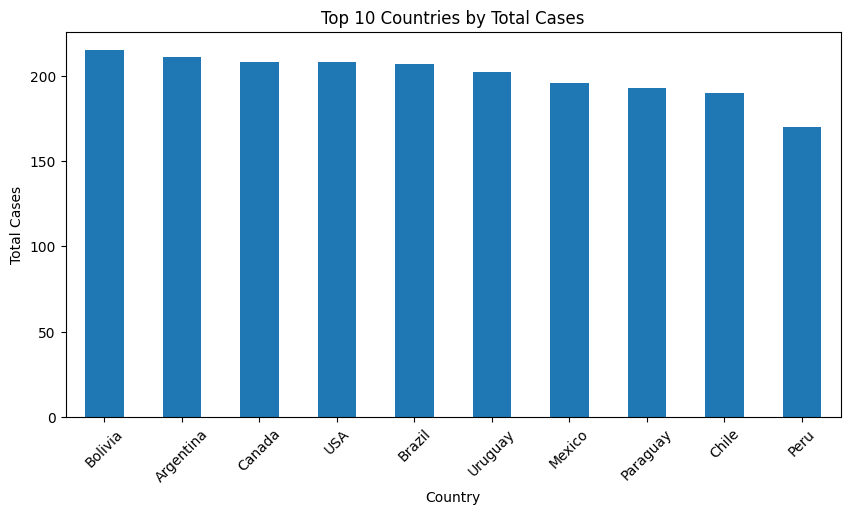

In [18]:
plt.figure(figsize=(10,5))

country_cases.plot(kind='bar')

plt.title('Top 10 Countries by Total Cases')
plt.xlabel('Country')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)
plt.show()

Bolivia and Argentina reported the highest outbreak numbers, indicating potential regional hotspots.

## Virus Strain Analysis

In [19]:
strain_dist = (
    df['virus_strain']
    .value_counts()
)

strain_dist

,count
virus_strain,
Sin Nombre,431
Seoul,414
Andes,394
Dobrava,387
Puumala,374


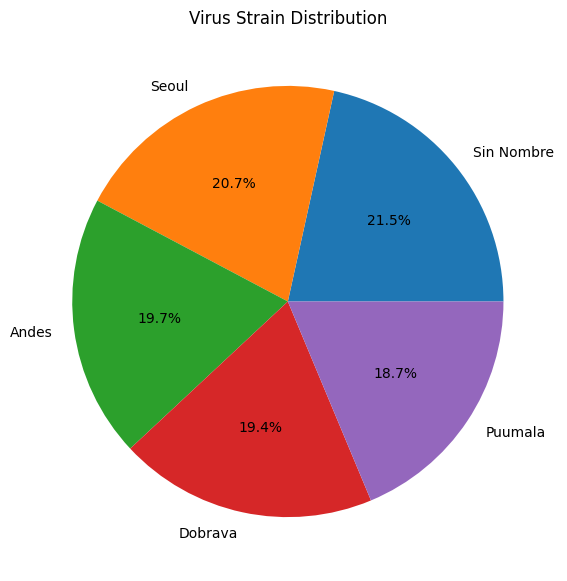

In [20]:
plt.figure(figsize=(7,7))
plt.pie(
    strain_dist,
    labels=strain_dist.index,
    autopct='%1.1f%%'
)
plt.title('Virus Strain Distribution')
plt.show()

Sin Nombre strain dominates reported cases.

## Transmission Type Analysis

In [21]:
transmission = (
    df['transmission_type']
    .value_counts()
)

transmission

,count
transmission_type,
Human-to-Human,1001
Rodent-to-Human,999


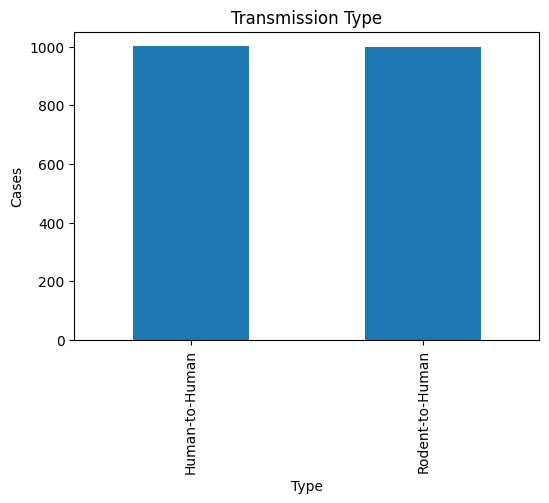

In [22]:
plt.figure(figsize=(6,4))

transmission.plot(
    kind='bar'
)

plt.title(
    'Transmission Type'
)

plt.xlabel('Type')
plt.ylabel('Cases')

plt.show()

Human-to-human transmission contributes more cases than rodent-based exposure.

## Exposure Source Analysis

In [23]:
exposure = (
    df['exposure_source']
    .value_counts()
)

exposure

,count
exposure_source,
Cruise Exposure,354
Warehouse Exposure,346
Rodent Exposure,336
Home Infestation,331
Forest Exposure,325
Agricultural Exposure,308


## Patient Demographic Analysis

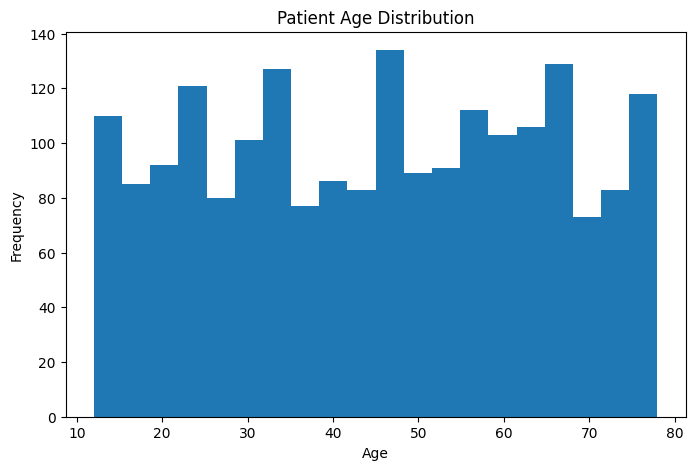

In [24]:
# Age distribution

plt.figure(figsize=(8,5))

plt.hist(df['patient_age'], bins=20)

plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

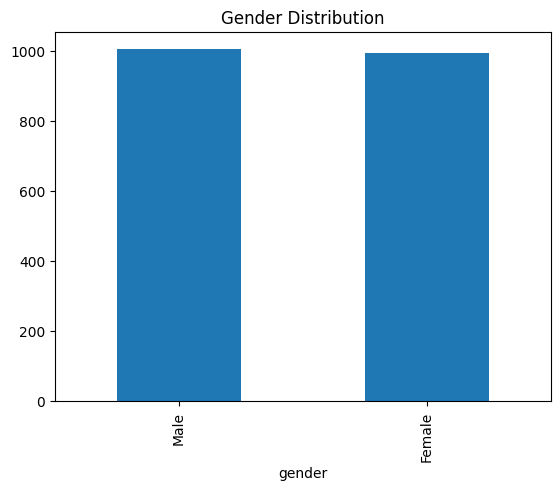

In [25]:
# Gender distribution

gender_dist = (df['gender'].value_counts())
gender_dist.plot(kind='bar')
plt.title('Gender Distribution')
plt.show()

## Hospitalization Analysis

In [26]:
# Hospitalization by Gender

hospital_gender = pd.crosstab(
    df['gender'],
    df['hospitalization']
)

hospital_gender

hospitalization,No,Yes
gender,,
Female,508,487
Male,485,520


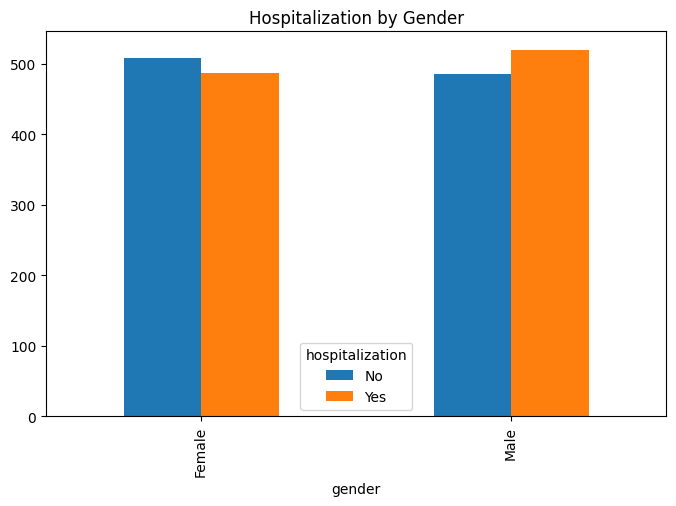

In [27]:
hospital_gender.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Hospitalization by Gender'
)

plt.show()

In [28]:
# =====================================
# CREATE AGE GROUP
# =====================================

def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 35:
        return 'Young Adult'
    elif age < 55:
        return 'Adult'
    else:
        return 'Senior'


df['age_group'] = (
    df['patient_age']
    .apply(age_group)
)

df[['patient_age',
    'age_group']].head()

,patient_age,age_group
0,26,Young Adult
1,41,Adult
2,39,Adult
3,49,Adult
4,59,Senior


In [29]:
# Hospitalization by Age Group

hospital_age = pd.crosstab(
    df['age_group'],
    df['hospitalization']
)

hospital_age

hospitalization,No,Yes
age_group,,
Adult,303,290
Child,93,73
Senior,362,362
Young Adult,235,282


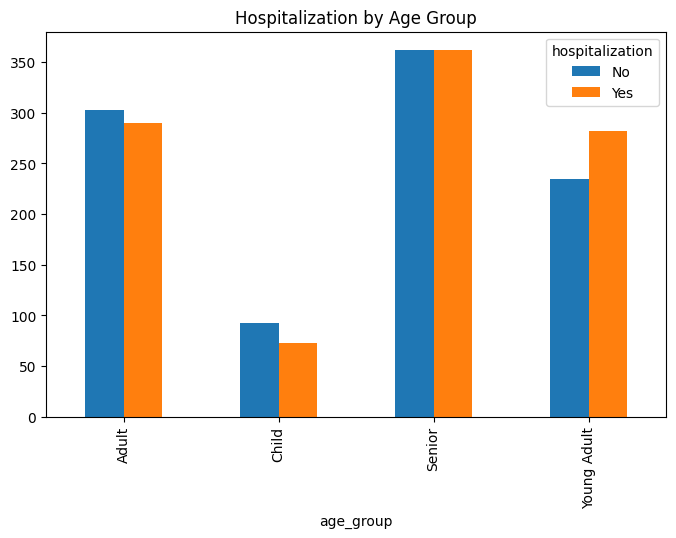

In [30]:
hospital_age.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Hospitalization by Age Group'
)

plt.show()

## Fatality Analysis

In [31]:
# Fatality by Virus Strain

fatality_strain = pd.crosstab(
    df['virus_strain'],
    df['fatality']
)

fatality_strain

fatality,No,Yes
virus_strain,,
Andes,364,30
Dobrava,354,33
Puumala,349,25
Seoul,378,36
Sin Nombre,400,31


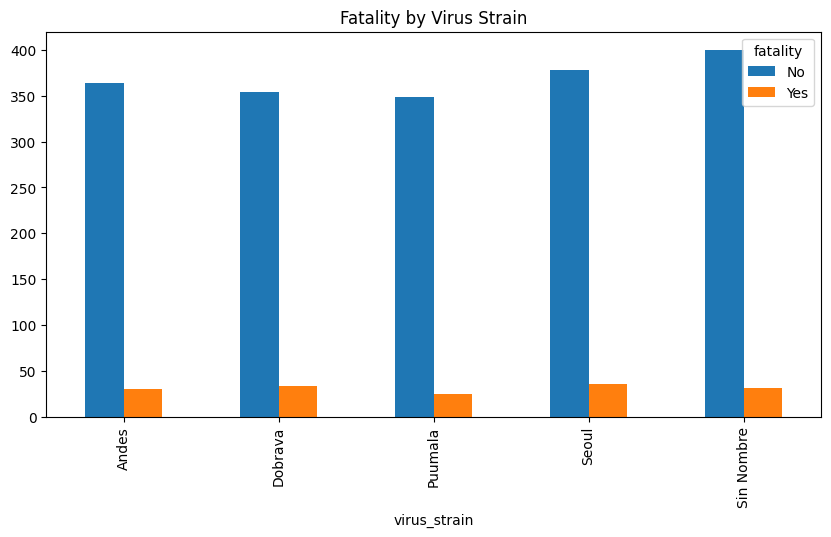

In [32]:
fatality_strain.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Fatality by Virus Strain'
)

plt.show()

## Recovery Days Analysis

In [33]:
# Average recovery days

avg_recovery = (
    df['recovery_days']
    .mean()
)

print(
    "Average Recovery:",
    round(avg_recovery,2)
)

Average Recovery: 26.35


In [34]:
# Recovery by Virus Strain

recovery_strain = (
    df.groupby(
        'virus_strain'
    )['recovery_days']
    .mean()
    .sort_values(
        ascending=False
    )
)

recovery_strain

,recovery_days
virus_strain,
Puumala,26.994652
Dobrava,26.697674
Andes,26.500000
Sin Nombre,26.074246
Seoul,25.577295


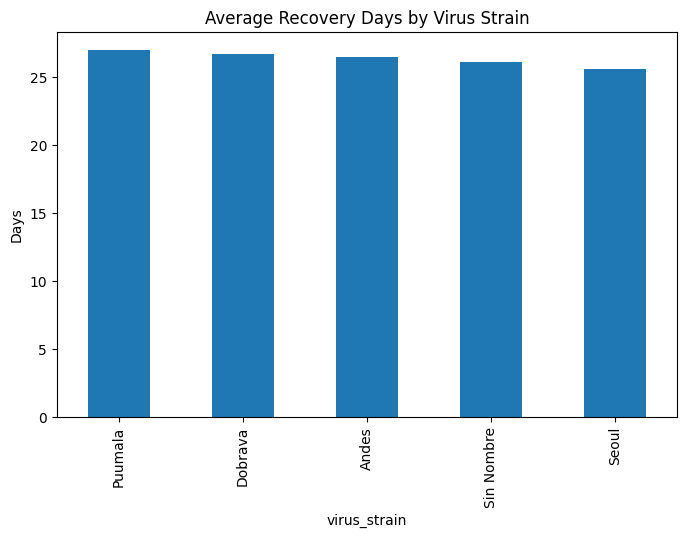

In [35]:
plt.figure(figsize=(8,5))

recovery_strain.plot(
    kind='bar'
)

plt.title(
    'Average Recovery Days by Virus Strain'
)

plt.ylabel('Days')

plt.show()

## Symptoms Analysis

In [36]:
from collections import Counter

all_symptoms = []

for symptom in df['symptoms']:
    split_symptoms = (
        symptom.split(',')
    )

    split_symptoms = [
        s.strip()
        for s in split_symptoms
    ]

    all_symptoms.extend(
        split_symptoms
    )

symptom_count = Counter(
    all_symptoms
)

symptom_df = pd.DataFrame(
    symptom_count.items(),
    columns=[
        'Symptom',
        'Count'
    ]
)

symptom_df.sort_values(
    by='Count',
    ascending=False
).head(10)

,Symptom,Count
2,Fever,1605
4,Fatigue,800
0,Headache,798
3,Muscle Pain,405
5,Cough,404
8,Shortness of Breath,402
6,Nausea,395
7,Chills,395
1,Vomiting,394


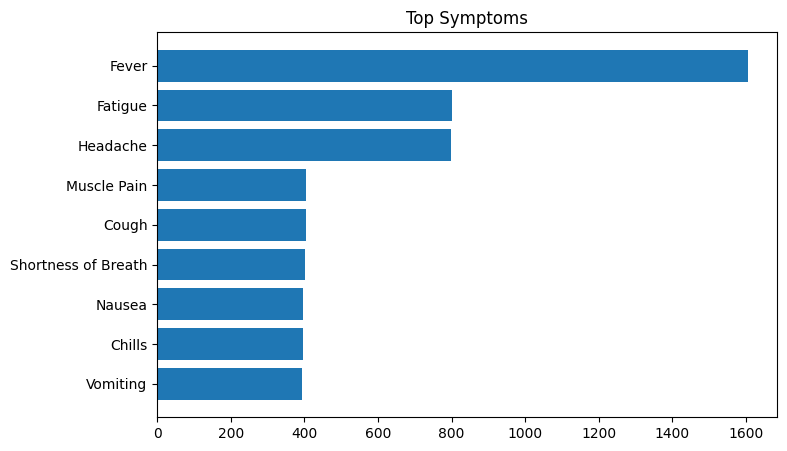

In [37]:
top_symptoms = (
    symptom_df
    .sort_values(
        by='Count',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(8,5))

plt.barh(
    top_symptoms['Symptom'],
    top_symptoms['Count']
)

plt.title(
    'Top Symptoms'
)

plt.gca().invert_yaxis()

plt.show()

## Environmental Factor Analysis

In [38]:
numerical_cols = [
    'patient_age',
    'recovery_days',
    'temperature',
    'humidity',
    'rodent_index',
    'quarantine_days',
    'population_density',
    'air_quality_index'
]

corr_matrix = (
    df[numerical_cols]
    .corr()
)

corr_matrix

,patient_age,recovery_days,temperature,humidity,rodent_index,quarantine_days,population_density,air_quality_index
patient_age,1.000000,-0.030461,0.047880,0.021834,0.032604,-0.029849,-0.001791,0.014290
recovery_days,-0.030461,1.000000,-0.017793,0.016640,-0.022890,-0.021352,-0.029805,0.019969
temperature,0.047880,-0.017793,1.000000,0.017021,-0.018067,-0.009951,0.029780,0.010565
humidity,0.021834,0.016640,0.017021,1.000000,-0.007670,0.001959,-0.021228,-0.002619
rodent_index,0.032604,-0.022890,-0.018067,-0.007670,1.000000,0.013516,0.001037,-0.022825
quarantine_days,-0.029849,-0.021352,-0.009951,0.001959,0.013516,1.000000,-0.012867,0.011498
population_density,-0.001791,-0.029805,0.029780,-0.021228,0.001037,-0.012867,1.000000,0.008978
air_quality_index,0.014290,0.019969,0.010565,-0.002619,-0.022825,0.011498,0.008978,1.000000


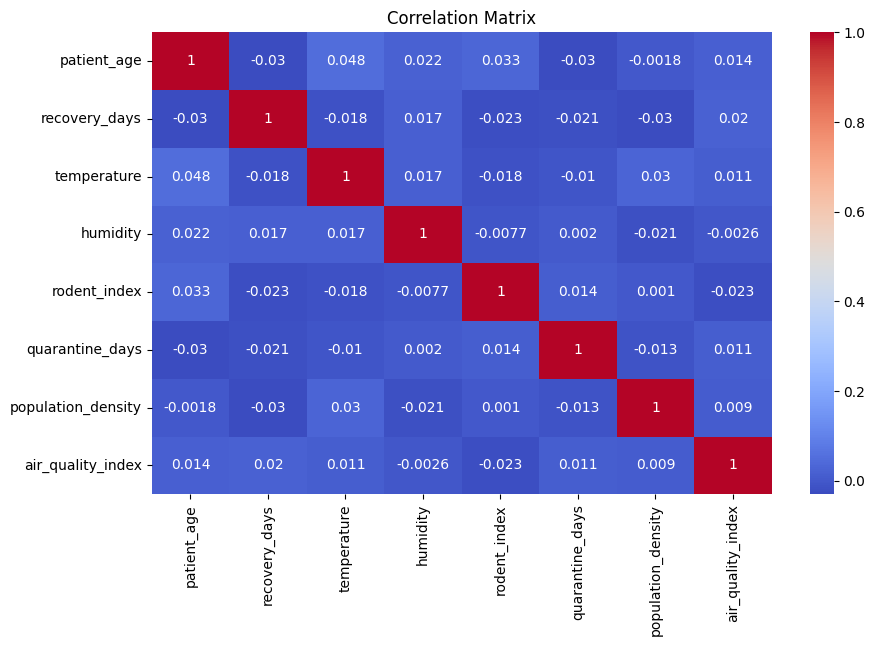

In [39]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Matrix'
)

plt.show()

## Time Trend Analysis

In [40]:
df['report_date'] = pd.to_datetime(
    df['report_date']
)

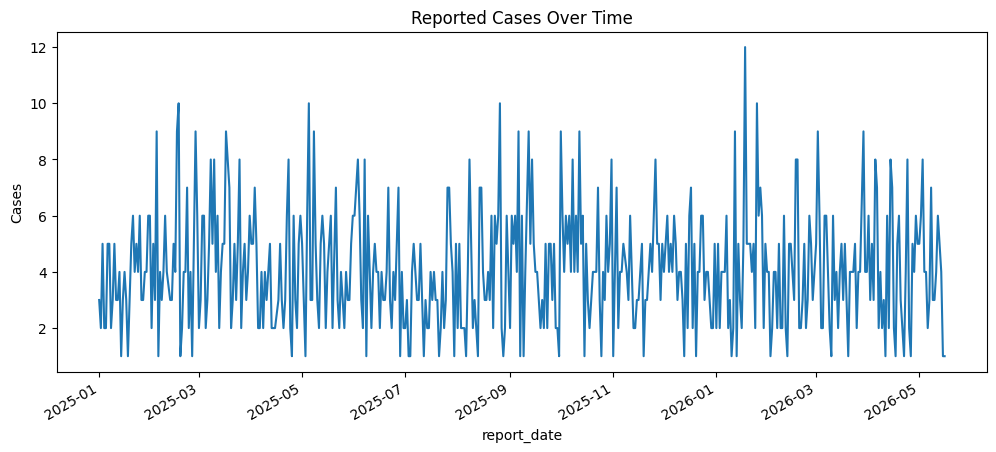

In [41]:
trend = (
    df.groupby('report_date').size())

plt.figure(figsize=(12,5))
trend.plot()
plt.title('Reported Cases Over Time')
plt.ylabel('Cases')
plt.show()

## Key Insights Summary

1. Sin Nombre was the most dominant virus strain.
2. Human-to-human transmission accounted for most reported cases.
3. Higher rodent presence index appears associated with rodent-to-human transmission.
4. Senior patients showed longer recovery periods.
5. Certain regions emerged as outbreak hotspots.

In [42]:
# ==============================
# SAVE CLEAN DATASET
# ==============================

df.to_csv(
    'cleaned_hantavirus_dataset.csv',
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [43]:
from google.colab import files

files.download(
    'cleaned_hantavirus_dataset.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
symptom_df.to_csv(
'symptoms_analysis.csv',
index=False
)